<a href="https://colab.research.google.com/github/amoghsharma6996/AmoghKumarSharma23BDS0063/blob/main/EDA_Phase1_Amogh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA on Student Performance Dataset (Phase 1)

**Name:** Amogh Kumar Sharma
**Reg No:** 23BDS0063

Dataset: [student-mat.csv](https://raw.githubusercontent.com/salemprakash/EDA/main/Data/student-mat.csv) — Student Math Performance dataset.

This notebook covers all the Phase 1 tasks:
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis
7. Bivariate analysis
8. Multivariate analysis


## 0. Importing required libraries
Basic libraries needed for loading data, doing stats, and plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


## 1. Loading the Dataset
Reading the CSV file directly from the GitHub raw link given in the assignment.

In [2]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/student-mat.csv"

# Load from the local copy in this repo; fall back to the raw GitHub link
# if the file isn't present (e.g. first run in a fresh Colab session).
import os
if os.path.exists("student-mat.csv"):
    df = pd.read_csv("student-mat.csv")
else:
    df = pd.read_csv(url)

# checking first 5 rows to see if it loaded properly
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# checking shape of dataset -> (rows, columns)
print("Shape of dataset:", df.shape)

# checking column names
print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [4]:
# quick info about datatypes and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         393 non-null    str  
 2   age         395 non-null    int64
 3   address     394 non-null    str  
 4   famsize     394 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   393 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## 2. Applying Basic Statistical Analysis
Using `describe()` to get mean, std, min, max, quartiles etc. for the numeric columns.
Also checking value counts for a few categorical columns.

In [5]:
# statistical summary of all numeric columns
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
# describe() for categorical columns too
df.describe(include='object')


/tmp/ipykernel_146/1584984177.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,393,394,394,395,395,395,395,395,393,395,395,395,395,395,395,395
unique,2,2,3,2,3,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,304,280,348,141,217,145,273,343,242,214,201,314,375,329,263


In [7]:
# checking some individual stats for the final grade column (G3)
print("Mean of G3:", df['G3'].mean())
print("Median of G3:", df['G3'].median())
print("Mode of G3:", df['G3'].mode()[0])
print("Std Dev of G3:", df['G3'].std())
print("Variance of G3:", df['G3'].var())


Mean of G3: 10.415189873417722
Median of G3: 11.0
Mode of G3: 10
Std Dev of G3: 4.5814426109978434
Variance of G3: 20.989616397866733


## 3. Handling Missing Data
Checking if there are any missing/null values in the dataset. This particular dataset is usually clean
(no missing values), but we still check properly instead of assuming.

In [8]:
# checking null values column-wise
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
school        0
sex           2
age           0
address       1
famsize       1
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     2
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values in dataset: 6


In [9]:
# Even though this dataset does not have missing values,
# writing the handling code anyway so the pipeline is complete
# for numeric columns -> fill missing with median.
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# for categorical columns -> fill missing with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# confirming no missing values remain
print("Missing values after handling:", df.isnull().sum().sum())


Missing values after handling: 0


/tmp/ipykernel_146/289123060.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## 4. Data Cleaning
Checking for duplicate rows and any obvious inconsistencies in the data.

In [10]:
# checking for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# dropping duplicates if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (395, 33)


In [11]:
# checking unique values in some categorical columns to spot any weird/inconsistent entries
for col in ['school', 'sex', 'address', 'famsize', 'Pstatus', 'higher', 'internet']:
    print(col, "->", df[col].unique())


school -> <StringArray>
['GP', 'MS']
Length: 2, dtype: str
sex -> <StringArray>
['F', 'M']
Length: 2, dtype: str
address -> <StringArray>
['U', 'R', '?']
Length: 3, dtype: str
famsize -> <StringArray>
['GT3', 'LE3']
Length: 2, dtype: str
Pstatus -> <StringArray>
['A', 'T', '?']
Length: 3, dtype: str
higher -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
internet -> <StringArray>
['no', 'yes']
Length: 2, dtype: str


In [12]:
# stripping any extra spaces from column names,
df.columns = df.columns.str.strip()

# resetting index after dropping duplicates so index stays continuous
df = df.reset_index(drop=True)


## 5. Data Transformation
Creating a couple of new/derived columns and encoding categorical variables so that they
can be used later for analysis (like correlation, multivariate plots etc.)

In [13]:
# Grades G1, G2, G3 are on a 0-20 scale, adding an average grade column
df['avg_grade'] = (df['G1'] + df['G2'] + df['G3']) / 3
# just a simple bucketing: Low / Medium / High
def grade_bucket(g):
    if g < 10:
        return 'Low'
    elif g < 15:
        return 'Medium'
    else:
        return 'High'

df['performance'] = df['G3'].apply(grade_bucket)

df[['G1', 'G2', 'G3', 'avg_grade', 'performance']].head()


,G1,G2,G3,avg_grade,performance
0,5,6,6,5.666667,Low
1,5,5,6,5.333333,Low
2,7,8,10,8.333333,Medium
3,15,14,15,14.666667,High
4,6,10,10,8.666667,Medium


In [14]:
# label encoding some binary categorical columns (yes/no -> 1/0) so they're easier to use in plots/corr
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    df[col + '_enc'] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols + [c + '_enc' for c in binary_cols]].head()


,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,schoolsup_enc,famsup_enc,paid_enc,activities_enc,nursery_enc,higher_enc,internet_enc,romantic_enc
0,yes,no,no,no,yes,yes,no,no,1,0,0,0,1,1,0,0
1,no,yes,no,no,no,yes,yes,no,0,1,0,0,0,1,1,0
2,yes,no,yes,no,yes,yes,yes,no,1,0,1,0,1,1,1,0
3,no,yes,yes,yes,yes,yes,yes,yes,0,1,1,1,1,1,1,1
4,no,yes,yes,no,yes,yes,no,no,0,1,1,0,1,1,0,0


## 6. Univariate Analysis
Looking at individual columns one at a time. Using histograms, count plots and a box plot.

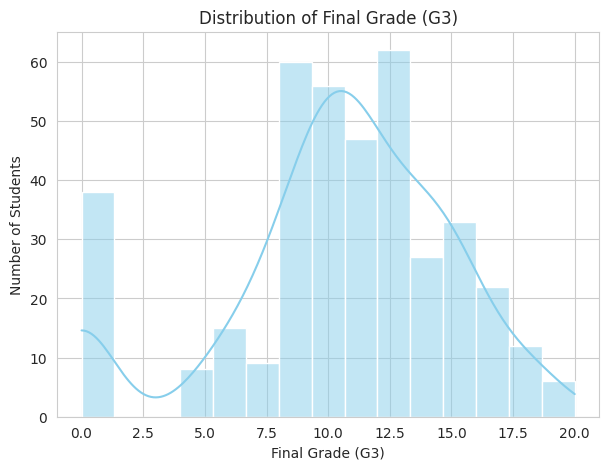

In [15]:
# Plot 1: Histogram of final grade (G3)
plt.figure(figsize=(7,5))
sns.histplot(df['G3'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()


/tmp/ipykernel_146/2828327130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


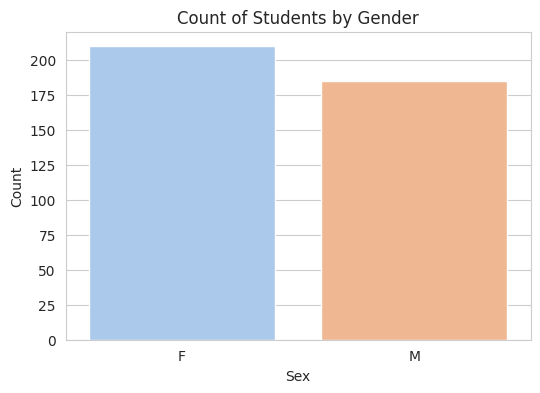

In [16]:
# Plot 2: Count plot of students by sex
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df, palette='pastel')
plt.title("Count of Students by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


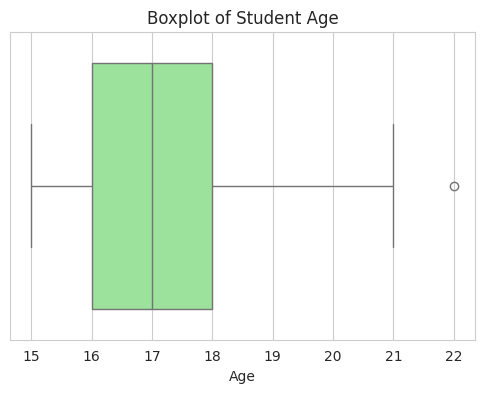

In [17]:
# Plot 3: Box plot for age to check spread and outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'], color='lightgreen')
plt.title("Boxplot of Student Age")
plt.xlabel("Age")
plt.show()


/tmp/ipykernel_146/1866400911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='studytime', data=df, palette='muted')


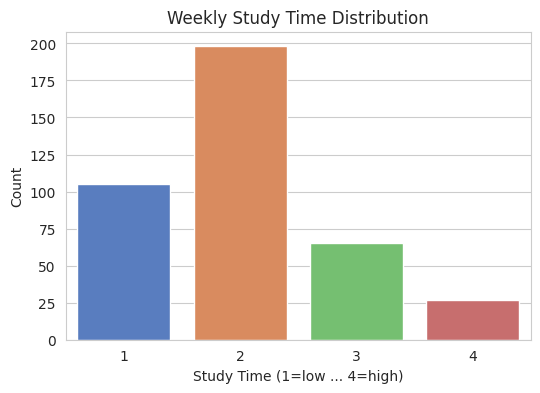

In [18]:
# Plot 4 (extra): Distribution of weekly study time
plt.figure(figsize=(6,4))
sns.countplot(x='studytime', data=df, palette='muted')
plt.title("Weekly Study Time Distribution")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Count")
plt.show()


## 7. Bivariate Analysis
Looking at relationship between two variables at a time.

/tmp/ipykernel_146/3700648513.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')


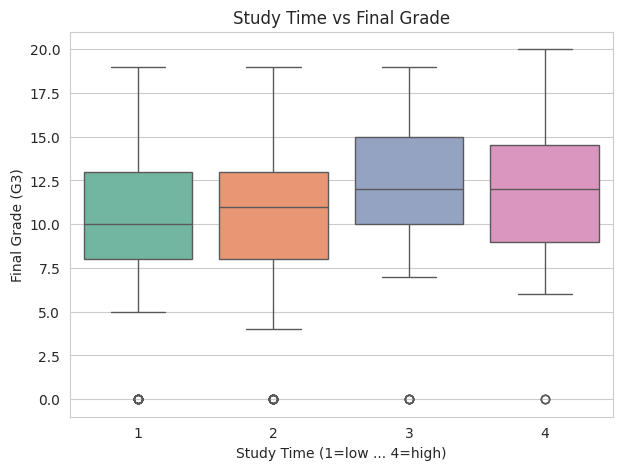

In [19]:
# Plot 1: Study time vs Final grade
plt.figure(figsize=(7,5))
sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Final Grade (G3)")
plt.show()


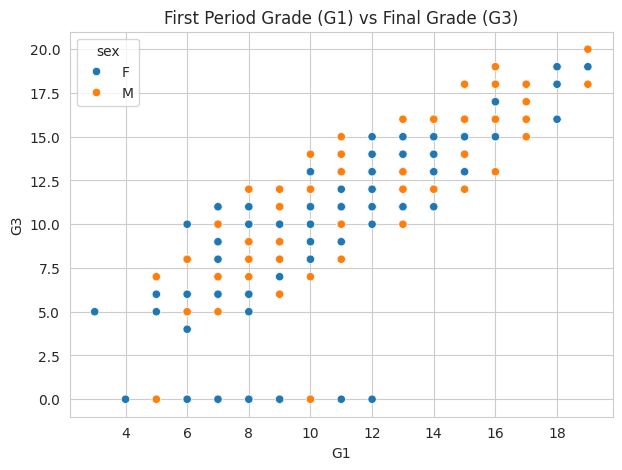

In [20]:
# Plot 2: Scatter plot - G1 vs G3 (first period grade vs final grade)
plt.figure(figsize=(7,5))
sns.scatterplot(x='G1', y='G3', data=df, hue='sex')
plt.title("First Period Grade (G1) vs Final Grade (G3)")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()


/tmp/ipykernel_146/2626768506.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)
/tmp/ipykernel_146/2626768506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)


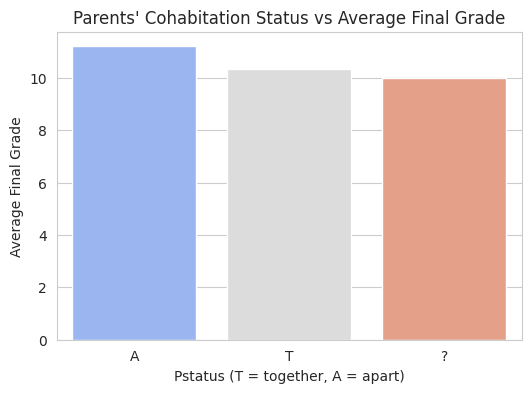

In [21]:
# Plot 3: Average final grade by parents' cohabitation status
plt.figure(figsize=(6,4))
sns.barplot(x='Pstatus', y='G3', data=df, palette='coolwarm', ci=None)
plt.title("Parents' Cohabitation Status vs Average Final Grade")
plt.xlabel("Pstatus (T = together, A = apart)")
plt.ylabel("Average Final Grade")
plt.show()


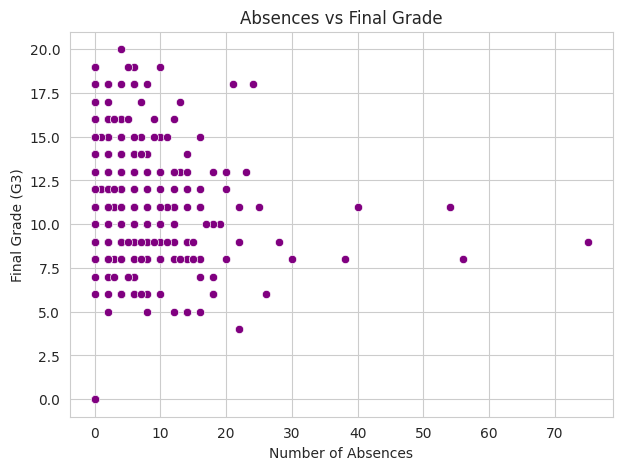

In [22]:
# Plot 4 (extra): Correlation between absences and final grade
plt.figure(figsize=(7,5))
sns.scatterplot(x='absences', y='G3', data=df, color='purple')
plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.show()


## 8. Multivariate Analysis
Looking at relationships between 3 or more variables together.

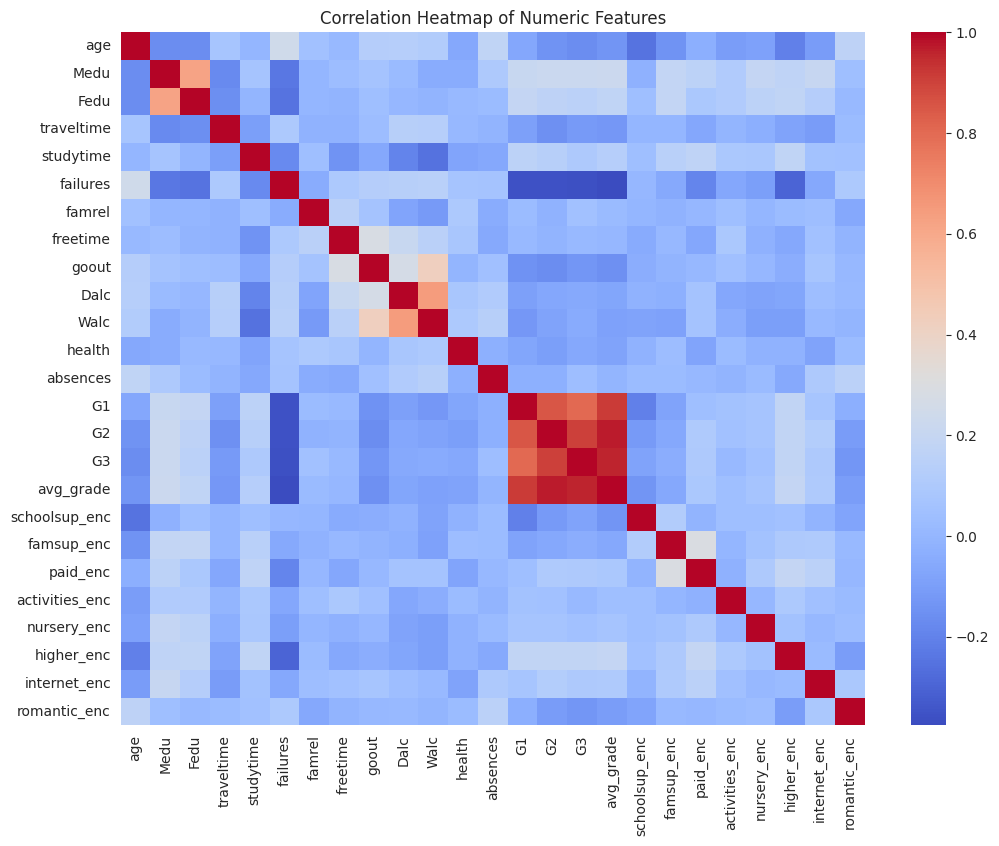

In [23]:
# Plot 1: Correlation heatmap of numeric columns
plt.figure(figsize=(12,9))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


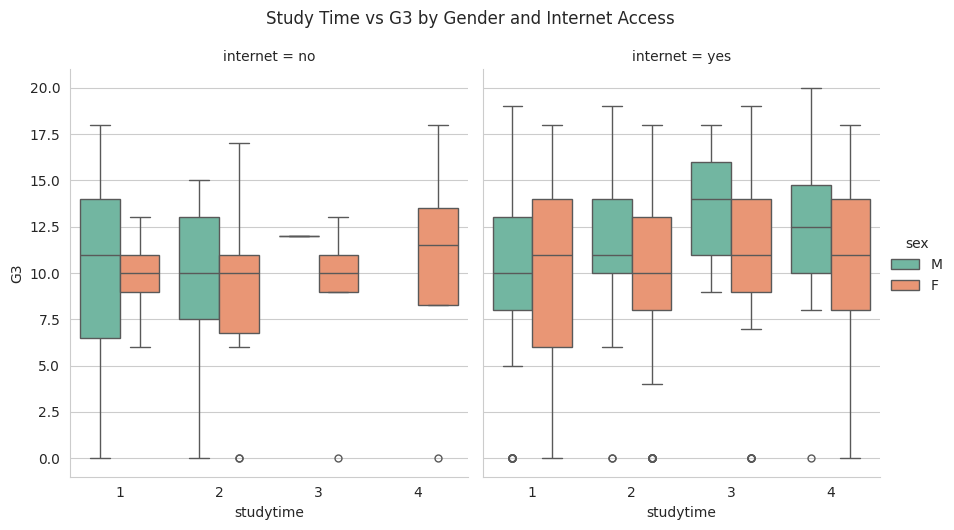

In [24]:
# Plot 2: Study time vs G3, split by gender (hue) and internet access (col)
g = sns.catplot(x='studytime', y='G3', hue='sex', col='internet',
                 data=df, kind='box', palette='Set2', height=5, aspect=0.9)
g.fig.suptitle("Study Time vs G3 by Gender and Internet Access", y=1.05)
plt.show()


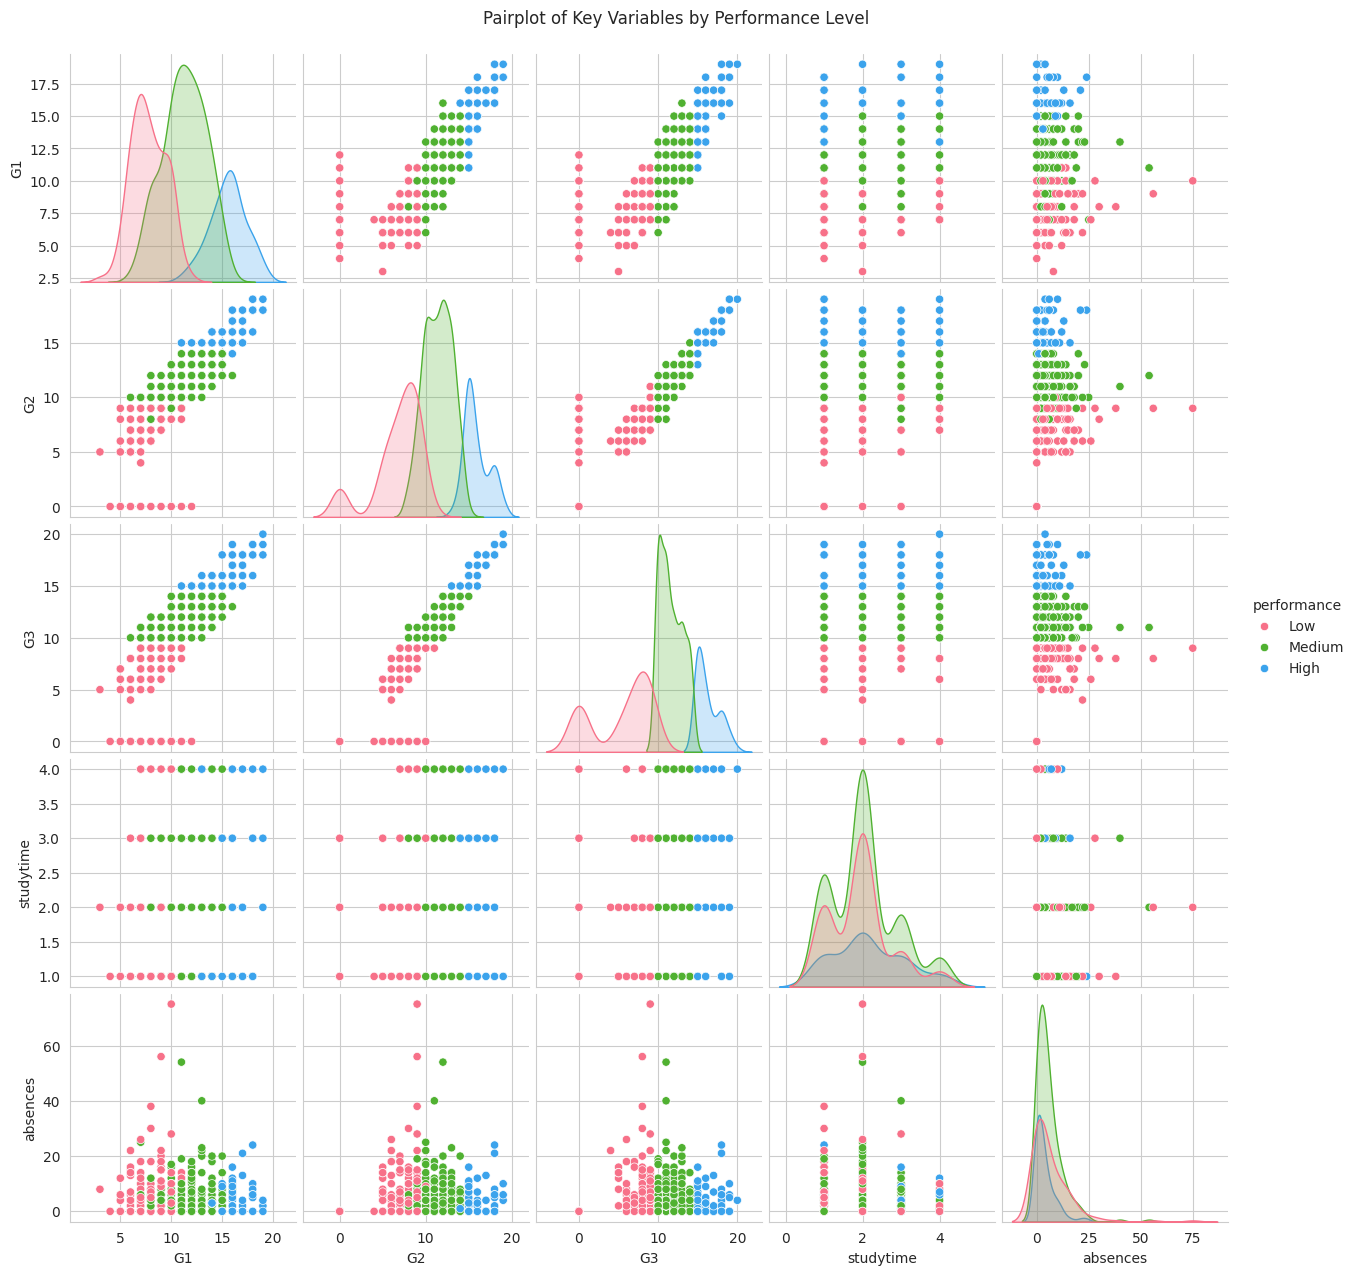

In [25]:
# Plot 3: Pairplot of a few important numeric columns, colored by performance bucket
cols_to_plot = ['G1', 'G2', 'G3', 'studytime', 'absences', 'performance']
sns.pairplot(df[cols_to_plot], hue='performance', palette='husl')
plt.suptitle("Pairplot of Key Variables by Performance Level", y=1.02)
plt.show()


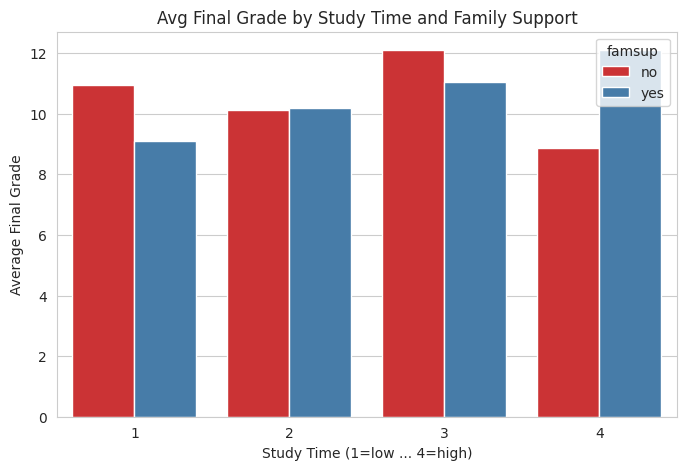

In [26]:
# Plot 4 : Avg final grade by study time and family support, grouped bar chart
pivot_df = df.groupby(['studytime', 'famsup'])['G3'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='studytime', y='G3', hue='famsup', data=pivot_df, palette='Set1')
plt.title("Avg Final Grade by Study Time and Family Support")
plt.xlabel("Study Time (1=low ... 4=high)")
plt.ylabel("Average Final Grade")
plt.show()


## Conclusion (Phase 1)

- The dataset had no major missing values, but the missing-value handling step was still included for completeness.
- Duplicate rows were checked and removed (if any existed).
- New columns (`avg_grade`, `performance`) were created during transformation to help with later analysis.
- From the univariate plots, most students score in the mid-range for final grades, and study time is fairly skewed towards lower values (1-2).
- From the bivariate plots, there seems to be a positive relation between study time and final grade, and a strong positive relation between G1/G2 and G3 (expected, since they are earlier grades in the same subject).
- The correlation heatmap and pairplot in the multivariate section show G1, G2 and G3 are highly correlated with each other, while other features like absences have weaker correlation with final grade.

This completes all Phase 1 requirements.


# Phase 2 – Statistical Analysis (1D / 2D / 3D) and Clustering

**Name:** Amogh Kumar Sharma
**Reg No:** 23BDS0063

Phase 1 covered loading, cleaning, transforming and basic univariate/bivariate/multivariate plots.
Phase 2 goes deeper into the statistics side and adds clustering:

9. 1D (Univariate) Statistical Analysis
10. 2D (Bivariate) Statistical Analysis
11. 3D (Multivariate) Statistical Analysis
12. K-Means Clustering
13. Hierarchical Clustering

This uses the same `df` that was already loaded and cleaned in Phase 1, so run all the Phase 1 cells above first.

## Extra imports needed for Phase 2
`scipy` for statistical tests + distance/linkage, `sklearn` for scaling/clustering/regression, and
`mplot3d` for the 3D plot.

**Note on R equivalents:** this notebook is kept in Python (per the assignment instructions — same
notebook, not a new one), so wherever the brief asks for an R function, the equivalent Python call is
used and noted in a comment: `e1071::skewness`/`kurtosis` → `scipy.stats.skew`/`kurtosis`,
`prop.table()` → `pd.crosstab(..., normalize=...)`, `aggregate()` → `groupby().agg()`, `cor()` →
`.corr()`/`scipy.stats.pearsonr`/`spearmanr`, `dist()` → `scipy.spatial.distance.pdist`, `hclust()` →
`scipy.cluster.hierarchy.linkage`, `cutree()` → `fcluster`, `kmeans()` → `sklearn.cluster.KMeans`,
`scale()` → `sklearn.preprocessing.StandardScaler`.


In [27]:
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression

from mpl_toolkits.mplot3d import Axes3D


## Q2-3. Summary Statistics (1D)
Computing Mean, Median, Min, Max, Range, Variance, Std Dev, IQR, Skewness and Kurtosis for the three
key numeric columns (`G3`, `absences`, `studytime`), storing everything in one structured DataFrame.
Skewness/Kurtosis use `scipy.stats.skew`/`kurtosis` with `bias=False`, matching R's
`e1071::skewness`/`kurtosis` (type = 2) — the standard "sample" adjusted versions.

In [28]:
cols_1d = ['G3', 'absences', 'studytime']

summary_stats = pd.DataFrame({
    col: {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Minimum': df[col].min(),
        'Maximum': df[col].max(),
        'Range': df[col].max() - df[col].min(),
        'Variance': df[col].var(),
        'Std_Dev': df[col].std(),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
        # scipy.stats.skew/kurtosis(bias=False) ~= e1071::skewness/kurtosis(type=2) in R
        'Skewness': stats.skew(df[col], bias=False),
        'Kurtosis': stats.kurtosis(df[col], bias=False)
    }
    for col in cols_1d
}).T

summary_stats.round(3)


,Mean,Median,Minimum,Maximum,Range,Variance,Std_Dev,IQR,Skewness,Kurtosis
G3,10.415,11.0,0.0,20.0,20.0,20.990,4.581,6.0,-0.733,0.403
absences,5.709,4.0,0.0,75.0,75.0,64.050,8.003,8.0,3.672,21.719
studytime,2.035,2.0,1.0,4.0,3.0,0.704,0.839,1.0,0.632,-0.014


## Q4. Frequency & Relative Frequency Distribution (Categorical Variable)
Using `internet` (does the student have internet access at home?) as the categorical variable.
`value_counts()` gives the frequency table; `value_counts(normalize=True)` gives the relative
frequency table — the Python equivalent of R's `table()` / `prop.table(table())`.

In [29]:
cat_var = 'internet'

freq_table = df[cat_var].value_counts()
rel_freq_table = df[cat_var].value_counts(normalize=True)   # equiv. to R's prop.table(table(x))

freq_dist = pd.DataFrame({'Frequency': freq_table, 'Relative_Frequency': rel_freq_table.round(4)})
freq_dist


,Frequency,Relative_Frequency
internet,,
yes,329,0.8329
no,66,0.1671


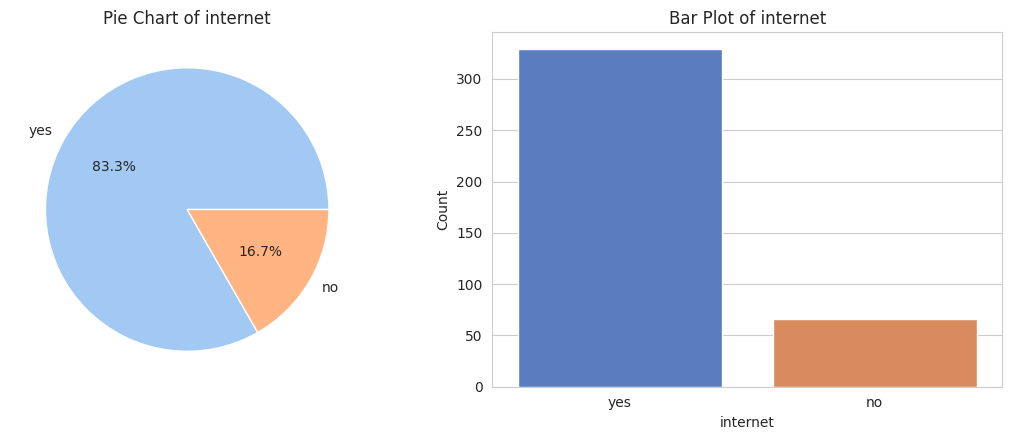

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].pie(freq_table, labels=freq_table.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title(f"Pie Chart of {cat_var}")

sns.barplot(x=freq_table.index, y=freq_table.values, hue=freq_table.index, palette='muted',
            legend=False, ax=axes[1])
axes[1].set_title(f"Bar Plot of {cat_var}")
axes[1].set_xlabel(cat_var)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Q5. Frequency Distribution with Bin Intervals (Numerical Variable)
Binning `G3` (final grade, 0-20) into intervals and building a frequency table over the bins, then a
histogram and a box plot to check for outliers.

In [31]:
num_var = 'G3'
bins = [0, 5, 10, 15, 20]
bin_labels = ['0-5', '5-10', '10-15', '15-20']

g3_bins = pd.cut(df[num_var], bins=bins, labels=bin_labels, include_lowest=True)
binned_freq = g3_bins.value_counts().sort_index()
binned_freq_df = pd.DataFrame({'Bin_Interval': binned_freq.index, 'Frequency': binned_freq.values})
binned_freq_df


,Bin_Interval,Frequency
0,0-5,46
1,5-10,140
2,10-15,169
3,15-20,40


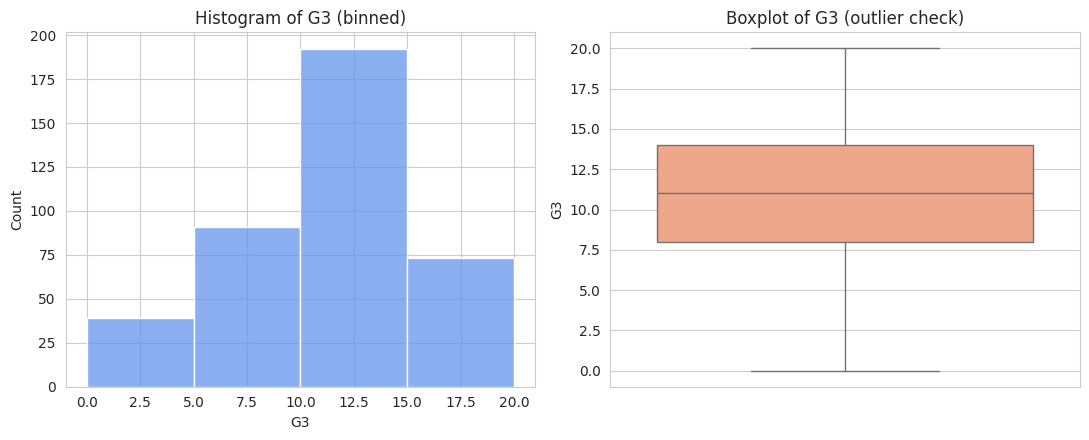

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df[num_var], bins=bins, kde=False, color='cornflowerblue', ax=axes[0])
axes[0].set_title(f"Histogram of {num_var} (binned)")
axes[0].set_xlabel(num_var)

sns.boxplot(y=df[num_var], color='lightsalmon', ax=axes[1])
axes[1].set_title(f"Boxplot of {num_var} (outlier check)")

plt.tight_layout()
plt.show()


## Q6. Contingency Table (Two Categorical Variables)
Cross-tabulating `sex` and `internet`, then row and column percentages — the equivalent of R's
`prop.table(table(x, y), margin = 1)` (row %) and `margin = 2` (column %).

In [33]:
cat1, cat2 = 'sex', 'internet'

contingency = pd.crosstab(df[cat1], df[cat2])
row_pct = pd.crosstab(df[cat1], df[cat2], normalize='index') * 100     # prop.table(..., margin=1)
col_pct = pd.crosstab(df[cat1], df[cat2], normalize='columns') * 100   # prop.table(..., margin=2)

print("Contingency table (counts):")
print(contingency)
print("\nRow percentages (%):")
print(row_pct.round(2))
print("\nColumn percentages (%):")
print(col_pct.round(2))


Contingency table (counts):
internet  no  yes
sex              
F         38  172
M         28  157

Row percentages (%):
internet     no    yes
sex                   
F         18.10  81.90
M         15.14  84.86

Column percentages (%):
internet     no    yes
sex                   
F         57.58  52.28
M         42.42  47.72


## Q7. Stacked / Grouped Bar Plot (sex vs internet)

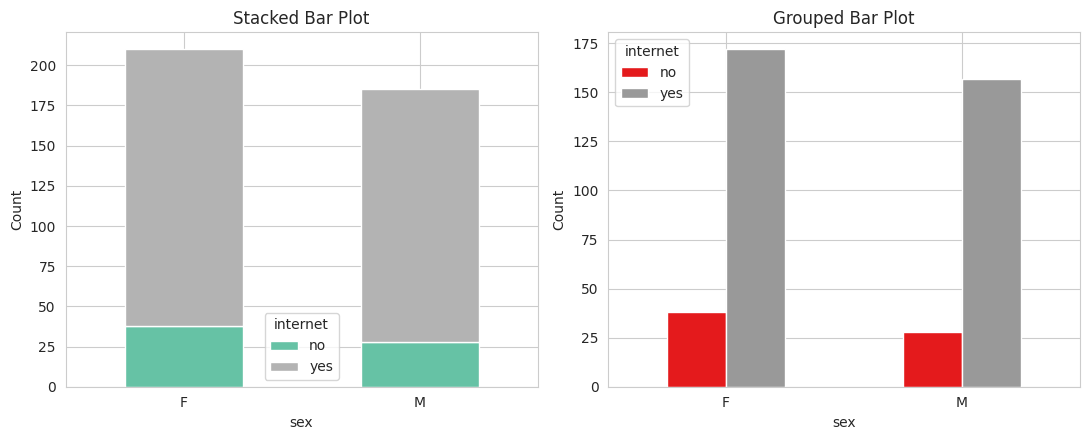

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

contingency.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title("Stacked Bar Plot")
axes[0].set_xlabel(cat1)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

contingency.plot(kind='bar', stacked=False, ax=axes[1], colormap='Set1')
axes[1].set_title("Grouped Bar Plot")
axes[1].set_xlabel(cat1)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Q8. Grouped Summary Statistics (Categorical + Numerical)
Mean, median and standard deviation of `G3` grouped by `studytime`, using `groupby().agg()`
— the Python equivalent of R's `aggregate(G3 ~ studytime, data = df, FUN = ...)`.

In [35]:
grouped_stats = df.groupby('studytime')['G3'].agg(['mean', 'median', 'std']).round(3)
grouped_stats.columns = ['Mean', 'Median', 'Std_Dev']
grouped_stats


,Mean,Median,Std_Dev
studytime,,,
1,10.048,10.0,4.956
2,10.172,11.0,4.218
3,11.400,12.0,4.640
4,11.259,12.0,5.281


## Q9. Side-by-Side Box Plots and Violin Plot
Visualizing how `G3` is distributed across the 4 `studytime` categories.

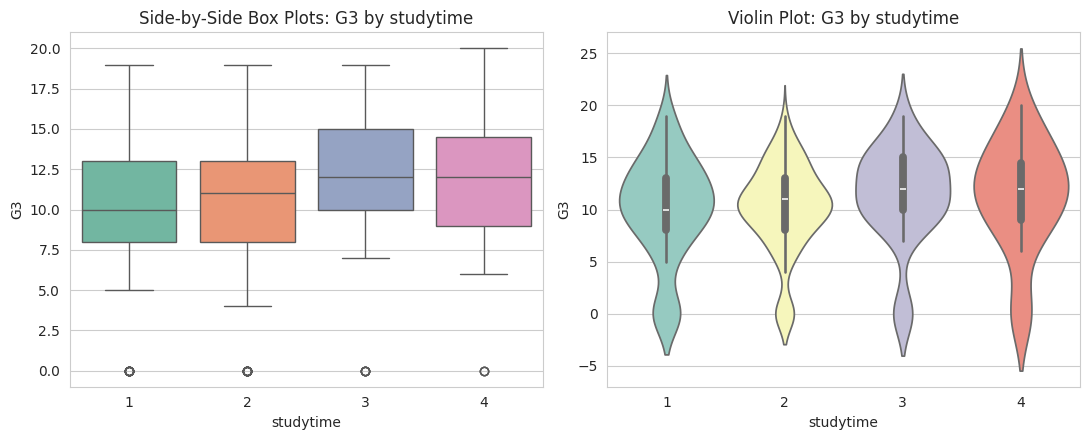

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(x='studytime', y='G3', hue='studytime', data=df, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Side-by-Side Box Plots: G3 by studytime")

sns.violinplot(x='studytime', y='G3', hue='studytime', data=df, palette='Set3', legend=False, ax=axes[1])
axes[1].set_title("Violin Plot: G3 by studytime")

plt.tight_layout()
plt.show()


## Q10. Pearson & Spearman Correlation + Scatter with Regression Line
Between `G1` (first period grade) and `G3` (final grade).

Pearson correlation:  r = 0.801, p = 9.001e-90
Spearman correlation: r = 0.878, p = 8.141e-128


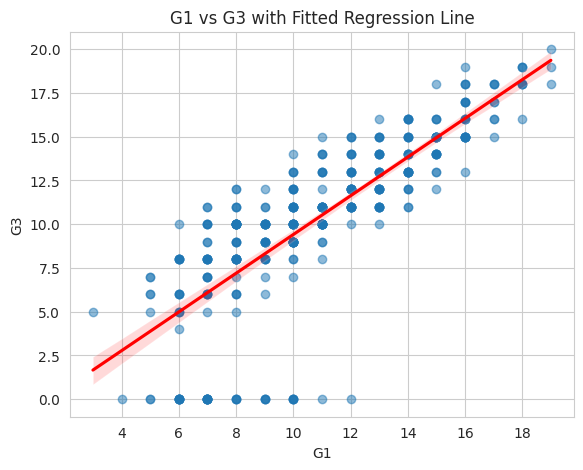

In [37]:
num1, num2 = 'G1', 'G3'

pearson_r, pearson_p = stats.pearsonr(df[num1], df[num2])   # equiv. to R's cor(x, y, method="pearson")
spearman_r, spearman_p = stats.spearmanr(df[num1], df[num2])  # equiv. to cor(x, y, method="spearman")

print(f"Pearson correlation:  r = {pearson_r:.3f}, p = {pearson_p:.4g}")
print(f"Spearman correlation: r = {spearman_r:.3f}, p = {spearman_p:.4g}")

plt.figure(figsize=(6.5, 5))
sns.regplot(x=num1, y=num2, data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title(f"{num1} vs {num2} with Fitted Regression Line")
plt.show()


## Q11. Two Categorical + One Numerical: Summary Stats, Faceted Box Plot, Grouped Bar with Error Bars
Using `sex` and `internet` (categorical) with `G3` (numerical).

In [38]:
combo_stats = df.groupby(['sex', 'internet'])['G3'].agg(['mean', 'std']).round(3)
combo_stats.columns = ['Mean', 'Std_Dev']
combo_stats


Mean  Std_Dev
sex internet                 
F   no         9.184    4.099
    yes       10.140    4.728
M   no         9.714    5.025
    yes       11.140    4.368

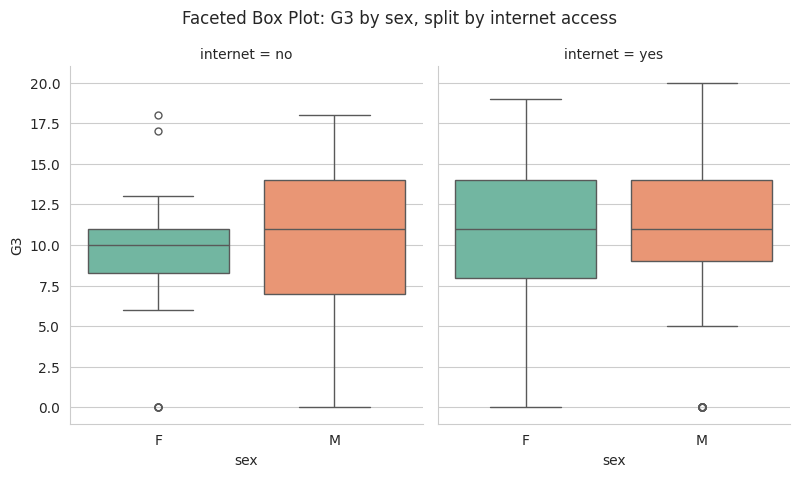

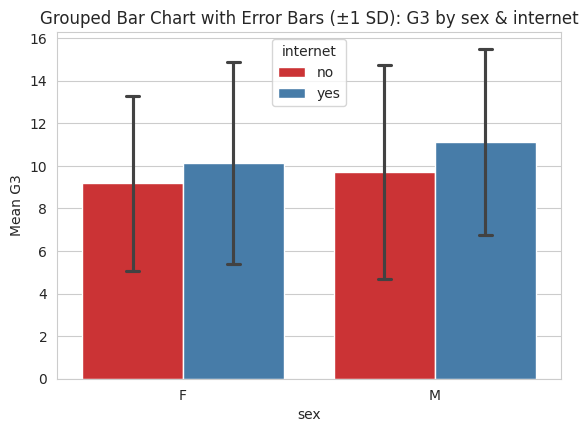

In [39]:
g = sns.catplot(x='sex', y='G3', hue='sex', col='internet', data=df, kind='box',
                 palette='Set2', height=4.5, aspect=0.9, legend=False)
g.fig.suptitle("Faceted Box Plot: G3 by sex, split by internet access", y=1.05)
plt.show()

plt.figure(figsize=(6.5, 4.5))
sns.barplot(x='sex', y='G3', hue='internet', data=df, palette='Set1', errorbar='sd', capsize=0.1)
plt.title("Grouped Bar Chart with Error Bars (±1 SD): G3 by sex & internet")
plt.ylabel("Mean G3")
plt.show()


## Q12. One Categorical + Two Numerical: Colored Scatter + Per-Category Correlation Matrix
Category: `internet`. Numerical features: `G1` and `G3`.

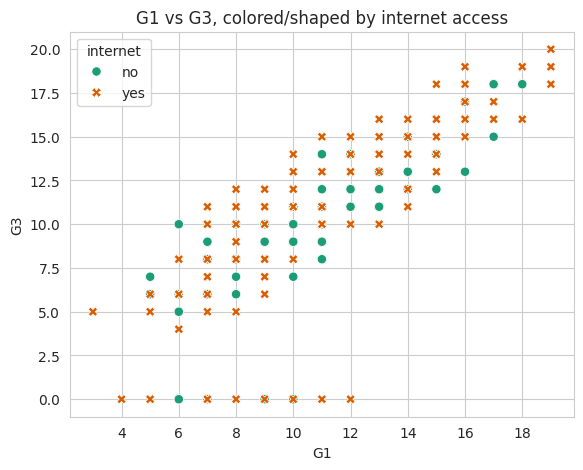

Correlation matrix for internet = 'no':
       G1     G3
G1  1.000  0.731
G3  0.731  1.000

Correlation matrix for internet = 'yes':
       G1     G3
G1  1.000  0.813
G3  0.813  1.000



In [40]:
plt.figure(figsize=(6.5, 5))
sns.scatterplot(x='G1', y='G3', hue='internet', style='internet', data=df, palette='Dark2', s=45)
plt.title("G1 vs G3, colored/shaped by internet access")
plt.show()

for level in sorted(df['internet'].unique()):
    sub = df[df['internet'] == level][['G1', 'G3']]
    print(f"Correlation matrix for internet = '{level}':")
    print(sub.corr().round(3))
    print()


## Q13. Correlation Matrix (3+ Numerical Features) + Heatmap

              G1     G2     G3  absences  studytime  failures
G1         1.000  0.852  0.801    -0.031      0.161    -0.355
G2         0.852  1.000  0.905    -0.032      0.136    -0.356
G3         0.801  0.905  1.000     0.034      0.098    -0.360
absences  -0.031 -0.032  0.034     1.000     -0.063     0.064
studytime  0.161  0.136  0.098    -0.063      1.000    -0.174
failures  -0.355 -0.356 -0.360     0.064     -0.174     1.000


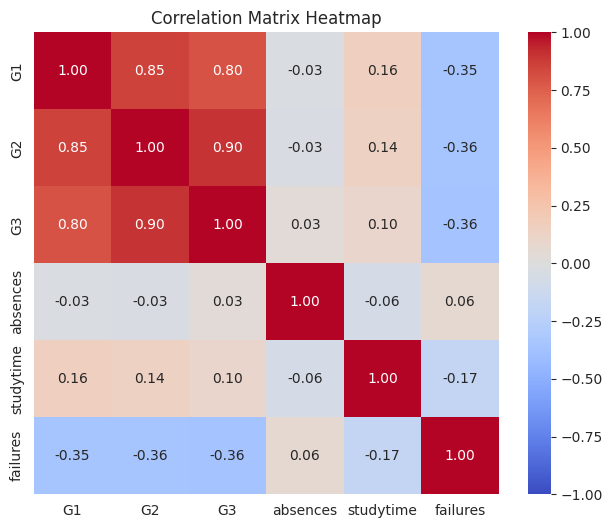

In [41]:
corr_features = ['G1', 'G2', 'G3', 'absences', 'studytime', 'failures']
corr_matrix = df[corr_features].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()


## Q14. Pairs Plot / Scatterplot Matrix

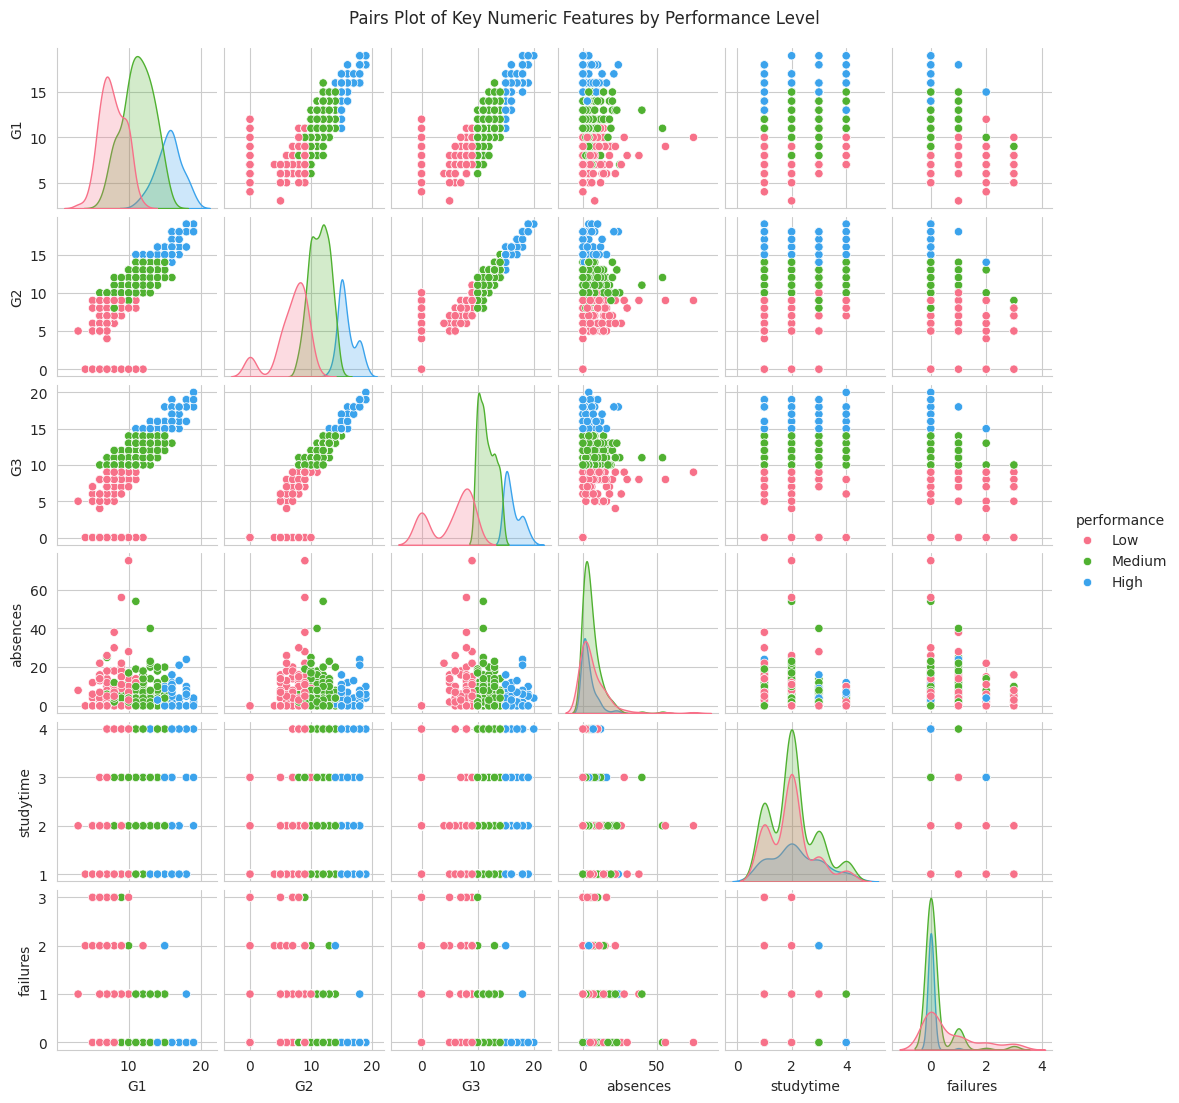

In [42]:
sns.pairplot(df[corr_features + ['performance']], hue='performance', palette='husl', height=1.8)
plt.suptitle("Pairs Plot of Key Numeric Features by Performance Level", y=1.02)
plt.show()


## 3D (Multivariate) Statistical Analysis
Correlation among `G1`, `G2`, `G3`, a 3D scatter plot of the same three grades colored by study time,
and a multiple linear regression predicting `G3` from `G1`, `G2` and `studytime`.

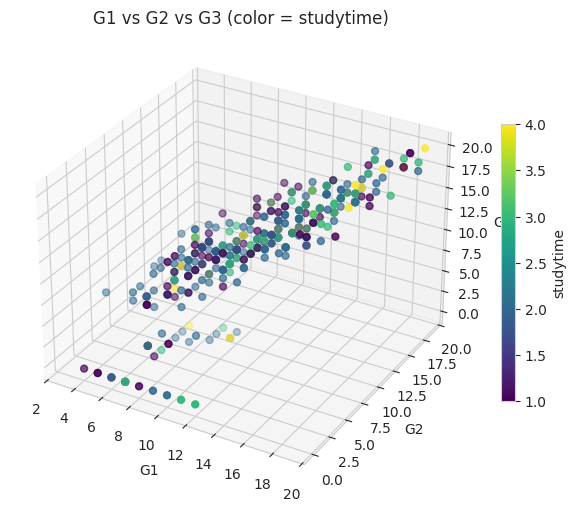

In [43]:
fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['G1'], df['G2'], df['G3'], c=df['studytime'], cmap='viridis', s=25)
ax.set_xlabel('G1'); ax.set_ylabel('G2'); ax.set_zlabel('G3')
ax.set_title("G1 vs G2 vs G3 (color = studytime)")
fig.colorbar(sc, ax=ax, shrink=0.6, label='studytime')
plt.show()


In [44]:
features_3d = ['G1', 'G2', 'studytime']
X = df[features_3d]
y = df['G3']

lin_reg = LinearRegression().fit(X, y)
print("Intercept:", round(lin_reg.intercept_, 3))
for feat, coef in zip(features_3d, lin_reg.coef_):
    print(f"Coefficient for {feat}: {coef:.3f}")
print(f"\nR-squared: {lin_reg.score(X, y):.3f}")


Intercept: -1.561
Coefficient for G1: 0.160
Coefficient for G2: 0.987
Coefficient for studytime: -0.169

R-squared: 0.823


## K-Means Clustering
Following the assignment's numbered steps.

**1-2. Load / view the dataset** — already loaded as `df` above.

In [45]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,avg_grade,performance,schoolsup_enc,famsup_enc,paid_enc,activities_enc,nursery_enc,higher_enc,internet_enc,romantic_enc
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,5.666667,Low,1,0,0,0,1,1,0,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5.333333,Low,0,1,0,0,0,1,1,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,8.333333,Medium,1,0,1,0,1,1,1,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,14.666667,High,0,1,1,1,1,1,1,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,8.666667,Medium,0,1,1,0,1,1,0,0


**3. Check missing values**

In [46]:
df.isnull().sum().sum()  # total missing values across the whole dataframe


np.int64(0)

**4. Check the dependent-variable distribution (table)**
Using `performance` (Low / Medium / High, derived from G3 in Phase 1) as the variable of interest.

In [47]:
df['performance'].value_counts()


performance
Medium    192
Low       130
High       73
Name: count, dtype: int64

**5. Select only numerical features for clustering (drop the rest)**

In [48]:
num_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
                'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
X_num = df[num_features]
X_num.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10


**6. Standardize the data**

In [49]:
scaler = StandardScaler()   # equiv. to R's scale()
X_scaled = scaler.fit_transform(X_num)
X_scaled[:5]


array([[ 1.02304645,  1.14385567,  1.36037064,  0.79225076, -0.04228585,
        -0.44994364,  0.06219406, -0.2360102 ,  0.8014793 , -0.54069866,
        -1.00378921, -0.39928949,  0.03642446, -1.78246688, -1.25479105,
        -0.96493392],
       [ 0.23837976, -1.60000865, -1.39997047, -0.64324947, -0.04228585,
        -0.44994364,  1.17886012, -0.2360102 , -0.09790798, -0.54069866,
        -1.00378921, -0.39928949, -0.21379577, -1.78246688, -1.52097927,
        -0.96493392],
       [-1.33095364, -1.60000865, -1.39997047, -0.64324947, -0.04228585,
         3.58932316,  0.06219406, -0.2360102 , -0.99729526,  0.58338539,
         0.55109996, -0.39928949,  0.53686493, -1.1791469 , -0.72241461,
        -0.0907392 ],
       [-1.33095364,  1.14385567, -0.47985677, -0.64324947,  1.15077909,
        -0.44994364, -1.054472  , -1.23841914, -0.99729526, -0.54069866,
        -1.00378921,  1.04106985, -0.464016  ,  1.23413302,  0.87471471,
         1.0020042 ],
       [-0.54628694,  0.22923423,  0

**7. Apply K-Means with centers = 2**

In [50]:
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
kmeans_k2


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


**8. Display K-Means results**

In [51]:
print("Cluster assignments (first 15 students):", kmeans_k2.labels_[:15])
print("\nCluster sizes:")
print(pd.Series(kmeans_k2.labels_).value_counts().sort_index())
print("\nInertia (WCSS) at k=2:", round(kmeans_k2.inertia_, 2))


Cluster assignments (first 15 students): [1 1 1 0 0 0 0 1 0 0 0 0 0 0 0]

Cluster sizes:
0    230
1    165
Name: count, dtype: int64

Inertia (WCSS) at k=2: 5460.87


**9. Display cluster centers**

In [52]:
centers_k2 = pd.DataFrame(kmeans_k2.cluster_centers_, columns=num_features)
centers_k2.round(3)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,-0.195,0.269,0.272,-0.169,0.170,-0.356,0.028,-0.105,-0.188,-0.213,-0.23,-0.077,-0.091,0.589,0.587,0.584
1,0.272,-0.375,-0.379,0.235,-0.238,0.497,-0.039,0.147,0.262,0.297,0.32,0.107,0.127,-0.821,-0.818,-0.814


**10-11. Calculate WCSS for K = 1 to 10 and plot the elbow curve**

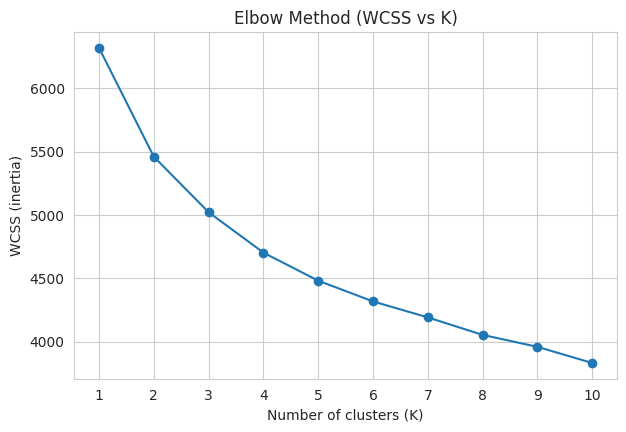

In [53]:
wcss = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), wcss, marker='o')
plt.title("Elbow Method (WCSS vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (inertia)")
plt.xticks(list(k_values))
plt.show()


**12. Apply K-Means based on the elbow recommendation**
The elbow curve flattens out noticeably around **K = 3**, so the final clustering uses `k = 3`.

Final K-Means (k=3) cluster sizes:
kmeans_cluster
0     98
1    146
2    151
Name: count, dtype: int64


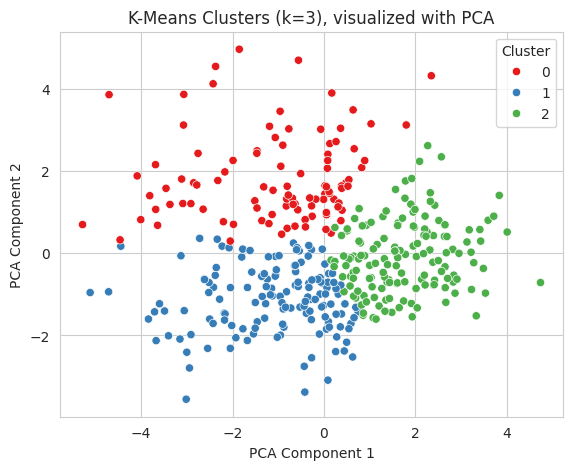

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
kmeans_cluster,,,,,,,,,,,,,,,,
0,17.05,2.90,2.64,1.68,1.69,0.50,3.82,3.70,3.99,2.58,3.84,3.90,8.53,10.07,10.02,9.80
1,16.74,2.16,2.06,1.48,2.13,0.51,3.92,3.00,2.92,1.13,1.80,3.50,5.16,8.55,7.95,7.02
2,16.42,3.22,2.89,1.26,2.17,0.05,4.05,3.16,2.72,1.11,1.76,3.38,4.41,13.73,13.83,14.10


In [54]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
df['kmeans_cluster'] = kmeans_final.labels_

print("Final K-Means (k=3) cluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
plt.figure(figsize=(6.5, 5))
sns.scatterplot(x=pca_coords[:, 0], y=pca_coords[:, 1], hue=df['kmeans_cluster'], palette='Set1')
plt.title("K-Means Clusters (k=3), visualized with PCA")
plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()

df.groupby('kmeans_cluster')[num_features].mean().round(2)


## Hierarchical Clustering
Following the assignment's numbered steps.

**1-3. Load / view the dataset / check missing values** — same `df`, already confirmed clean above.

**4-5. Select only numerical attributes and standardize** — reusing `X_num` and `X_scaled` from the
K-Means section (same features, same scaling).

In [55]:
X_num.describe().T[['mean', 'std', 'min', 'max']].round(2)


,mean,std,min,max
age,16.70,1.28,15.0,22.0
Medu,2.75,1.09,0.0,4.0
Fedu,2.52,1.09,0.0,4.0
traveltime,1.45,0.70,1.0,4.0
studytime,2.04,0.84,1.0,4.0
failures,0.33,0.74,0.0,3.0
famrel,3.94,0.90,1.0,5.0
freetime,3.24,1.00,1.0,5.0
goout,3.11,1.11,1.0,5.0
Dalc,1.48,0.89,1.0,5.0


**6. Calculate Euclidean distance**

In [56]:
euclidean_dist = pdist(X_scaled, metric='euclidean')   # equiv. to R's dist(X, method="euclidean")
dist_matrix = squareform(euclidean_dist)
print("Distance matrix shape:", dist_matrix.shape)
print("Example distance (student 0 to student 1):", round(euclidean_dist[0], 3))


Distance matrix shape: (395, 395)
Example distance (student 0 to student 1): 4.474


**7-8. Hierarchical clustering with Single, Complete, Average and Ward linkage — dendrograms**
`scipy.cluster.hierarchy.linkage()` is the equivalent of R's `hclust()`; the `method` argument selects
the linkage type.

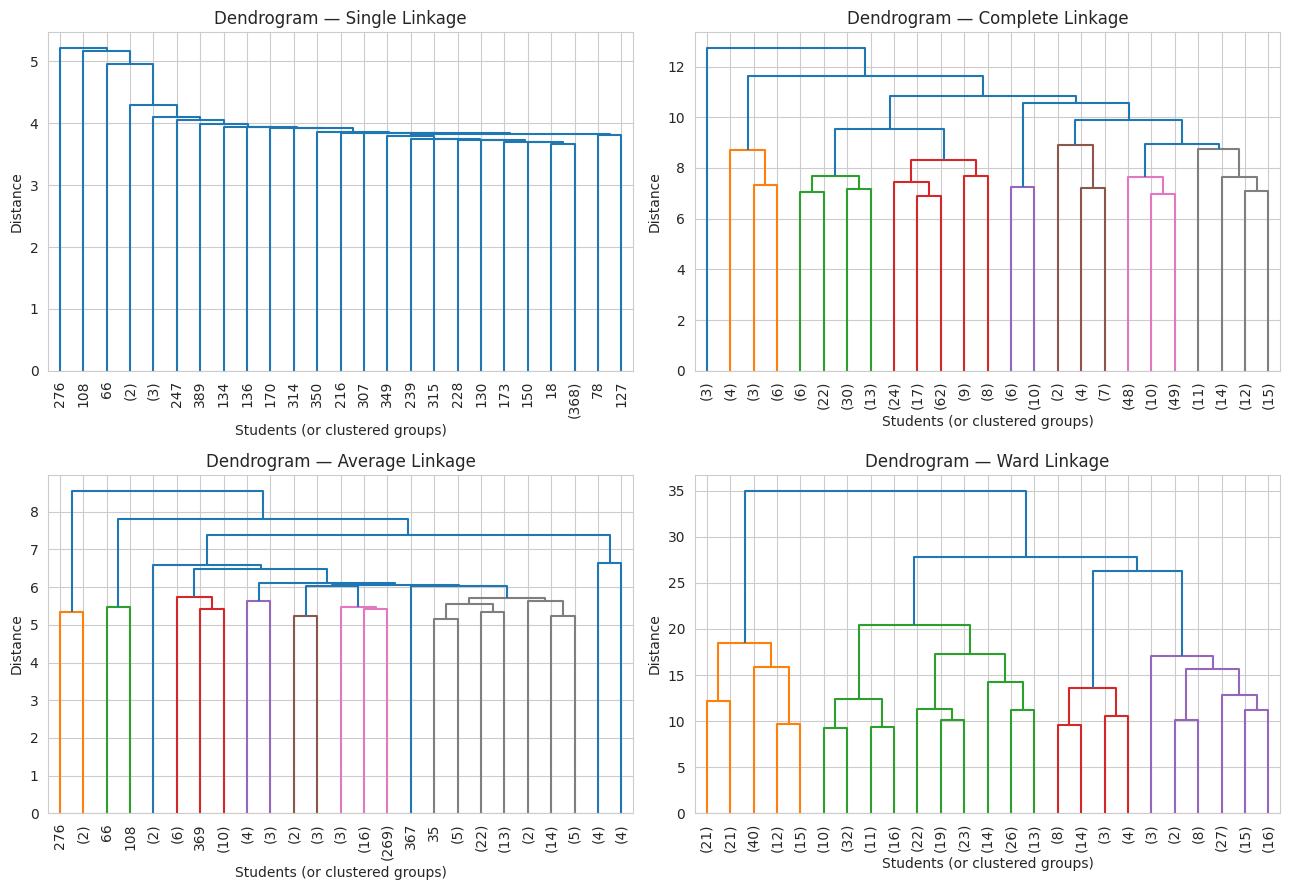

In [57]:
linkage_methods = ['single', 'complete', 'average', 'ward']
linkages = {m: linkage(X_scaled, method=m) for m in linkage_methods}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, m in zip(axes.ravel(), linkage_methods):
    dendrogram(linkages[m], truncate_mode='lastp', p=25, leaf_rotation=90, ax=ax)
    ax.set_title(f"Dendrogram — {m.capitalize()} Linkage")
    ax.set_xlabel("Students (or clustered groups)")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()


**9-10. Cut each tree into 3 clusters (`cutree` / `fcluster`) and show cluster sizes**

In [58]:
cluster_assignments = {}
for m in linkage_methods:
    labels = fcluster(linkages[m], t=3, criterion='maxclust')   # equiv. to R's cutree(hc, k=3)
    cluster_assignments[m] = labels
    print(f"{m.capitalize()} linkage — cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    print()

# Keeping the Ward-linkage assignment on the dataframe (most balanced clusters, comparable to K-Means)
df['hc_cluster'] = cluster_assignments['ward']
df.groupby('hc_cluster')[num_features].mean().round(2)


Single linkage — cluster sizes:
1    393
2      1
3      1
Name: count, dtype: int64

Complete linkage — cluster sizes:
1      3
2     13
3    379
Name: count, dtype: int64

Average linkage — cluster sizes:
1      3
2      2
3    390
Name: count, dtype: int64

Ward linkage — cluster sizes:
1    109
2    186
3    100
Name: count, dtype: int64



,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
hc_cluster,,,,,,,,,,,,,,,,
1,16.66,3.23,2.78,1.23,2.32,0.15,4.01,3.25,2.86,1.13,1.76,3.33,5.24,14.54,14.50,14.76
2,16.54,2.42,2.39,1.54,2.05,0.13,4.01,3.04,2.90,1.24,1.95,3.51,4.25,9.74,9.34,8.89
3,17.02,2.84,2.49,1.51,1.69,0.91,3.75,3.58,3.76,2.32,3.50,3.89,8.94,9.13,9.13,8.51


In [59]:
# Comparing K-Means (k=3) with Hierarchical (Ward, k=3) cluster assignments
comparison = pd.crosstab(df['kmeans_cluster'], df['hc_cluster'])
comparison.index.name = 'KMeans cluster'
comparison.columns.name = 'Hierarchical (Ward) cluster'
comparison


Hierarchical (Ward) cluster,1,2,3
KMeans cluster,,,
0,3,20,75
1,9,114,23
2,97,52,2


## Conclusion (Phase 2)

- **Summary statistics (Q2-3):** `G3` is close to symmetric with a mild left skew; `absences` is heavily
  right-skewed with a handful of high-absence outliers, which the box plot confirms.
- **Categorical distribution (Q4):** most students have internet access at home, visible in both the pie
  chart and bar plot.
- **Binned numerical distribution (Q5):** the bulk of students land in the 10-15 grade bucket.
- **Contingency table (Q6-7):** `sex` and `internet` access show only mild association once row/column
  percentages are compared.
- **Grouped stats (Q8-9):** average `G3` rises with `studytime`, and the box/violin plots show the spread
  widening slightly at higher study-time levels too.
- **Correlation (Q10):** `G1` and `G3` are strongly, positively correlated (both Pearson and Spearman),
  confirming first-period performance is a strong predictor of the final grade.
- **Two-categorical analysis (Q11-12):** grade differences by `sex`/`internet` combinations are modest;
  the `G1` vs `G3` relationship stays strongly positive within both internet-access groups.
- **Correlation matrix / pairs plot (Q13-14):** `G1`, `G2` and `G3` are all tightly correlated with each
  other, while `absences`, `studytime` and `failures` show weaker, more scattered relationships with the
  grades.
- **3D analysis:** the multiple regression using `G1`, `G2` and `studytime` explains most of the
  variation in `G3`, dominated by the two prior grades.
- **K-Means:** the elbow plot flattens around K = 3, giving 3 reasonably balanced student groups
  separated mainly by prior grades and failures.
- **Hierarchical clustering:** Ward linkage (cut at 3 clusters) produces group sizes and profiles broadly
  similar to K-Means, while single-linkage chains most points into one dominant cluster — a well-known
  effect of single linkage on this kind of data.
